In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import ROOT

In [16]:
# Asegurarse que AUGEROFFLINEROOT está definido
AugerOfflineRoot = os.environ.get("AUGEROFFLINEROOT")
if AugerOfflineRoot is None:
    raise EnvironmentError("AUGEROFFLINEROOT no definido. Hacé 'source this-auger-offline.sh' primero.")

# -----------------------------
# Cargar librerías Offline
# -----------------------------
libs_to_load = ["libRecEventKG.so"]
for lib in libs_to_load:
    ROOT.gSystem.Load(os.path.join(AugerOfflineRoot, "lib", lib))


In [17]:
# -----------------------------
# Funciones auxiliares para el MD
# -----------------------------
def getCounterList(sevent, mevent):
    """
    Obtener la lista de counters UMD asociados a las estaciones SD de un evento.

    Parameters
    ----------
    sevent : SDEvent
        Evento reconstruido de superficie.
    mevent : MDEvent
        Evento de muones detectados.

    Returns
    -------
    list of Counter
        Lista de counters (UMD) presentes en el evento.

    Notes
    -----
    Cada Counter representa una estación UMD:
      - Métodos importantes:
        - HasModule(modId) -> bool
        - GetModule(modId) -> Module
        - IsRejected() / IsSaturated() -> bool
      - Contiene módulos (scintillators) donde se detectan muones.
    """
    cList = []
    stationVector = sevent.GetStationVector()
    for station in stationVector:
        stationId = station.GetId()
        counterId = int("10" + str(stationId))
        if mevent.HasCounter(counterId):
            cList.append(mevent.GetCounter(counterId))
    return cList

def getModuleList(counter, sim=True):
    """
    Obtener la lista de módulos (scintillators) de un counter UMD.

    Parameters
    ----------
    counter : Counter
        Counter UMD del que se extraen los módulos.
    sim : bool, default=True
        Indica si es simulación (módulos 0-5) o dato real (100-115).

    Returns
    -------
    list of Module
        Lista de módulos válidos.

    Notes
    -----
    Cada Module contiene información de detección de muones:
      - Métodos importantes:
        - IsRejected() / IsSaturated() -> bool
        - Se puede extraer el número de muones detectados por módulo.
    """
    possibleModules = range(0,6) if sim else range(100,116)
    modules = []
    for modId in possibleModules:
        if counter.HasModule(modId):
            modules.append(counter.GetModule(modId))
    return modules


In [18]:
# -----------------------------
# Función principal de lectura
# -----------------------------
def readADST_surface(fname):
    """
    Leer archivos ADST y extraer información MC, SD y UMD para mapas de superficie.

    Parameters
    ----------
    fname : str or list of str
        Nombre(s) de archivo ADST a procesar.

    Returns
    -------
    pandas.DataFrame
        DataFrame por evento con columnas:
          - logE_MC, theta_MC, phi_MC, primary
          - logE_REC, theta_REC, phi_REC
          - coreUTM_X/Y, coreSite_X/Y
          - umdCounters : lista de diccionarios por cada counter con:
                counterId, nMuones, x_plane, y_plane, sdId, sdSignal
    """
    DataFiles = fname if isinstance(fname, list) else [fname]
    files = ROOT.std.vector('string')()
    for datfile in DataFiles:
        files.push_back(datfile)

    # Inicialización ADST
    file1 = ROOT.RecEventFile(files)
    event = ROOT.RecEvent()
    geo = ROOT.DetectorGeometry()
    file1.ReadDetectorGeometry(geo)
    file1.SetBuffers(event)

    data = []

    while file1.ReadNextEvent() == ROOT.RecEventFile.eSuccess:
        # ----------------- MC -----------------
        MCShower = event.GetGenShower()
        logE_MC = np.log10(MCShower.GetEnergy())
        theta_MC = MCShower.GetZenith() * 180.0/np.pi
        phi_MC = MCShower.GetAzimuth() * 180.0/np.pi
        primary = MCShower.GetShortPrimaryName()
        coreUTM = list(MCShower.GetCoreUTMCS())
        coreSite = list(MCShower.GetCoreSiteCS())

        # ----------------- REC -----------------
        sEvent = event.GetSDEvent()
        sShower = sEvent.GetSdRecShower()
        logE_REC = np.log10(sShower.GetEnergy())
        theta_REC = sShower.GetZenith() * 180.0/np.pi
        phi_REC = sShower.GetAzimuth() * 180.0/np.pi
        coreUTM_REC = list(sShower.GetCoreUTMCS())
        coreSite_REC = list(sShower.GetCoreSiteCS())

        # ----------------- MD -----------------
        mEvent = event.GetMDEvent()
        counterList = getCounterList(sEvent, mEvent)
        umdCounters = []

        for counter in counterList:
            print(f"Counter {counter.GetId()}:")
            modules = getModuleList(counter)
            for mod in modules:
                print(f"  Mod {mod.GetId()}, nMuones={mod.GetNumberOfEstimatedMuons()}")
 
            if counter.IsRejected() or counter.IsSaturated():
                continue

            # Número total de muones por counter
            nMuones = counter.GetNumberOfMuons()  # <--- aquí el cambio clave

            # Coordenadas SD asociadas
            sdId = counter.GetSdPartnerId()
            sdStation = sEvent.GetStationById(sdId) if sEvent.HasStation(sdId) else None
            if sdStation:
                r = sdStation.GetSPDistance()  # distancia al core en el plano de la lluvia
                phi_rel = sdStation.GetAzimuthSP() - sShower.GetAzimuth()  # diferencia azimutal
                x_plane = r * np.cos(phi_rel)
                y_plane = r * np.sin(phi_rel)
                r_core = r   # <-- agregamos distancia al core directamente
            else:
                x_plane, y_plane, r_core = None, None, None

            umdCounters.append({
                "counterId": counter.GetId(),
                "nMuones": nMuones,
                "x_plane": x_plane,
                "y_plane": y_plane,
                "r_core": r_core,        # <-- nueva columna
                "sdId": sdId,
                "sdSignal": sdStation.GetTotalSignal() if sdStation else None
            })
            
        data.append({
            "logE_MC": logE_MC, "theta_MC": theta_MC, "phi_MC": phi_MC, "primary": primary,
            "logE_REC": logE_REC, "theta_REC": theta_REC, "phi_REC": phi_REC,
            "coreUTM_X": coreUTM[0], "coreUTM_Y": coreUTM[1],
            "coreSite_X": coreSite[0], "coreSite_Y": coreSite[1],
            "umdCounters": umdCounters
        })

    df = pd.DataFrame(data)
    return df


  input file /home/lsilva/Github/ADST_Marina_prot_175/ADST_e17m316prot-epos_th00_DAT750960.root


Counter 104004:
  Mod 1, nMuones=260.38075481388523
  Mod 2, nMuones=216.79226562904813
  Mod 3, nMuones=191.42919646117352
Counter 104011:
  Mod 1, nMuones=0.9859784447534943
  Mod 2, nMuones=-0.0
  Mod 3, nMuones=0.9851073719436806
Counter 104013:
  Mod 1, nMuones=1.9877332124543914
  Mod 2, nMuones=0.9851073719436804
  Mod 3, nMuones=-0.0
Counter 104001:
  Mod 1, nMuones=-0.0
  Mod 2, nMuones=-0.0
  Mod 3, nMuones=-0.0
Counter 104005:
  Mod 1, nMuones=0.985978444753494
  Mod 2, nMuones=0.9851073719436806
  Mod 3, nMuones=-0.0
Counter 104012:
  Mod 1, nMuones=-0.0
  Mod 2, nMuones=-0.0
  Mod 3, nMuones=0.9851073719436804
Counter 104003:
  Mod 1, nMuones=0.985978444753494
  Mod 2, nMuones=-0.0
  Mod 3, nMuones=-0.0
Counter 104010:
  Mod 1, nMuones=-0.0
  Mod 2, nMuones=-0.0
  Mod 3, nMuones=-0.0
     logE_MC      theta_MC      phi_MC primary   logE_REC  theta_REC  \
0  17.500003  2.599192e-14  281.780657       p  17.280496   0.668314   

    phi_REC      coreUTM_X     coreUTM_Y    cor

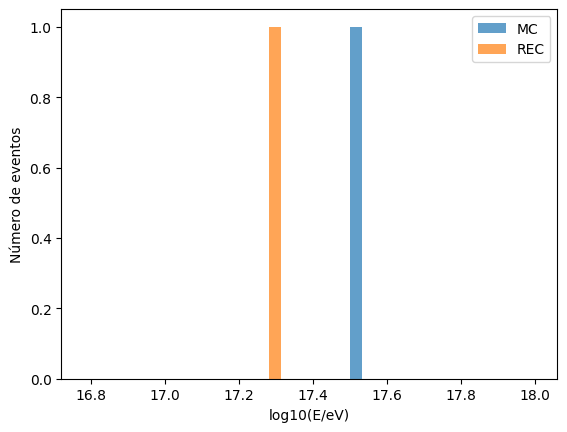

In [19]:
# -----------------------------
# Ejecutar
# -----------------------------
fname = "/home/lsilva/Github/ADST_Marina_prot_175/ADST_e17m316prot-epos_th00_DAT750960.root"
df = readADST_surface(fname)
print(df.head())

# Guardar en .npz
np.savez_compressed("ADST_simulation_marina_1_v5.npz", df=df.to_dict("list"))

# -----------------------------
# Plot rápido
# -----------------------------

plt.hist(df["logE_MC"], bins=30, alpha=0.7, label="MC")
plt.hist(df["logE_REC"], bins=30, alpha=0.7, label="REC")
plt.xlabel("log10(E/eV)")
plt.ylabel("Número de eventos")
plt.legend()
plt.show()

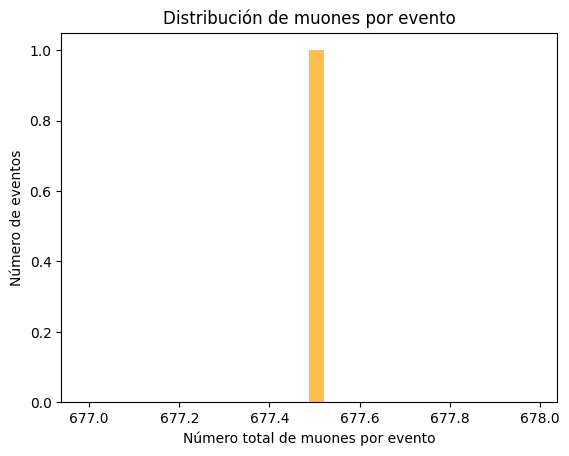

In [20]:
total_muones = [sum(c['nMuones'] for c in umdList) for umdList in df['umdCounters']]

plt.hist(total_muones, bins=30, color='orange', alpha=0.7)
plt.xlabel("Número total de muones por evento")
plt.ylabel("Número de eventos")
plt.title("Distribución de muones por evento")
plt.show()


In [21]:
counter_muones = {}
for umdList in df['umdCounters']:
    for c in umdList:
        counterId = c['counterId']
        counter_muones.setdefault(counterId, []).append(c['nMuones'])

for cid, vals in counter_muones.items():
    print(f"Counter {cid}: min={min(vals):.1f}, max={max(vals):.1f}, mean={sum(vals)/len(vals):.1f}")


Counter 104004: min=668.6, max=668.6, mean=668.6
Counter 104011: min=2.0, max=2.0, mean=2.0
Counter 104013: min=3.0, max=3.0, mean=3.0
Counter 104001: min=0.0, max=0.0, mean=0.0
Counter 104005: min=2.0, max=2.0, mean=2.0
Counter 104012: min=1.0, max=1.0, mean=1.0
Counter 104003: min=1.0, max=1.0, mean=1.0
Counter 104010: min=0.0, max=0.0, mean=0.0


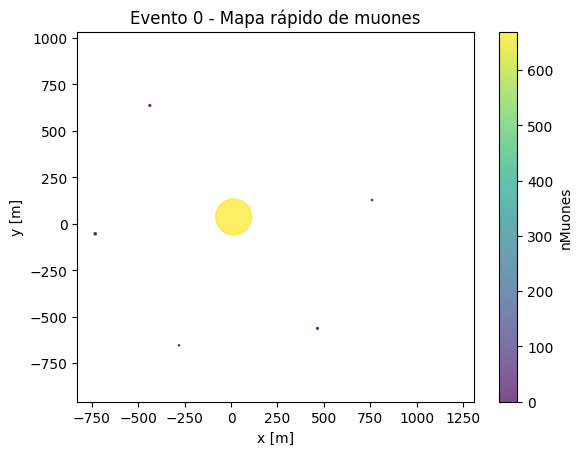

In [22]:
for event_idx, umdList in enumerate(df['umdCounters']):
    x = np.array([c['x_plane'] for c in umdList if c['x_plane'] is not None])
    y = np.array([c['y_plane'] for c in umdList if c['y_plane'] is not None])
    n = np.array([c['nMuones'] for c in umdList if c['x_plane'] is not None])
    
    plt.scatter(x, y, s=n, c=n, cmap='viridis', alpha=0.7)
    plt.colorbar(label="nMuones")
    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.title(f"Evento {event_idx} - Mapa rápido de muones")
    plt.axis('equal')
    plt.show()


  input file /home/lsilva/Github/ADST_Marina_prot_175/ADST_e17m316prot-epos_th22_DAT751255.root


Counter 104007:
  Mod 1, nMuones=17.741311985573148
  Mod 2, nMuones=15.342063168136427
  Mod 3, nMuones=11.720719139296161
Counter 104001:
  Mod 1, nMuones=0.9711989066637516
  Mod 2, nMuones=1.97314421647192
  Mod 3, nMuones=4.010993095227714
Counter 104002:
  Mod 1, nMuones=0.9711989066637516
  Mod 2, nMuones=6.117934613128456
  Mod 3, nMuones=0.9787418420347871
Counter 104017:
  Mod 1, nMuones=-0.0
  Mod 2, nMuones=0.9787418420347869
  Mod 3, nMuones=-0.0
Counter 104019:
  Mod 1, nMuones=0.9711989066637516
  Mod 2, nMuones=-0.0
  Mod 3, nMuones=0.9787418420347869
Counter 104006:
  Mod 1, nMuones=0.9711989066637516
  Mod 2, nMuones=-0.0
  Mod 3, nMuones=-0.0
Counter 104003:
  Mod 1, nMuones=-0.0
  Mod 2, nMuones=-0.0
  Mod 3, nMuones=-0.0
Counter 104004:
  Mod 1, nMuones=-0.0
  Mod 2, nMuones=-0.0
  Mod 3, nMuones=-0.0
Counter 104008:
  Mod 1, nMuones=1.9579376536548674
  Mod 2, nMuones=0.9787418420347869
  Mod 3, nMuones=0.9787418420347869
     logE_MC  theta_MC      phi_MC primary

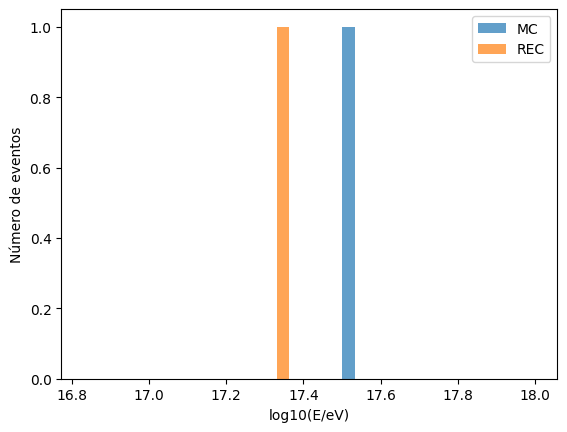

In [23]:
# -----------------------------
# Ejecutar
# -----------------------------
fname = "/home/lsilva/Github/ADST_Marina_prot_175/ADST_e17m316prot-epos_th22_DAT751255.root"
df = readADST_surface(fname)
print(df.head())

# Guardar en .npz
np.savez_compressed("ADST_simulation_marina_1_v5.npz", df=df.to_dict("list"))

# -----------------------------
# Plot rápido
# -----------------------------

plt.hist(df["logE_MC"], bins=30, alpha=0.7, label="MC")
plt.hist(df["logE_REC"], bins=30, alpha=0.7, label="REC")
plt.xlabel("log10(E/eV)")
plt.ylabel("Número de eventos")
plt.legend()
plt.show()

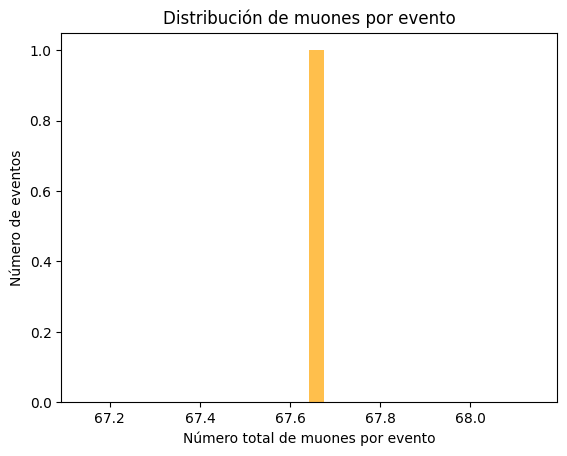

In [24]:
total_muones = [sum(c['nMuones'] for c in umdList) for umdList in df['umdCounters']]

plt.hist(total_muones, bins=30, color='orange', alpha=0.7)
plt.xlabel("Número total de muones por evento")
plt.ylabel("Número de eventos")
plt.title("Distribución de muones por evento")
plt.show()


In [25]:
counter_muones = {}
for umdList in df['umdCounters']:
    for c in umdList:
        counterId = c['counterId']
        counter_muones.setdefault(counterId, []).append(c['nMuones'])

for cid, vals in counter_muones.items():
    print(f"Counter {cid}: min={min(vals):.1f}, max={max(vals):.1f}, mean={sum(vals)/len(vals):.1f}")


Counter 104007: min=44.8, max=44.8, mean=44.8
Counter 104001: min=7.0, max=7.0, mean=7.0
Counter 104002: min=8.1, max=8.1, mean=8.1
Counter 104017: min=1.0, max=1.0, mean=1.0
Counter 104019: min=1.9, max=1.9, mean=1.9
Counter 104006: min=1.0, max=1.0, mean=1.0
Counter 104003: min=0.0, max=0.0, mean=0.0
Counter 104004: min=0.0, max=0.0, mean=0.0
Counter 104008: min=3.9, max=3.9, mean=3.9


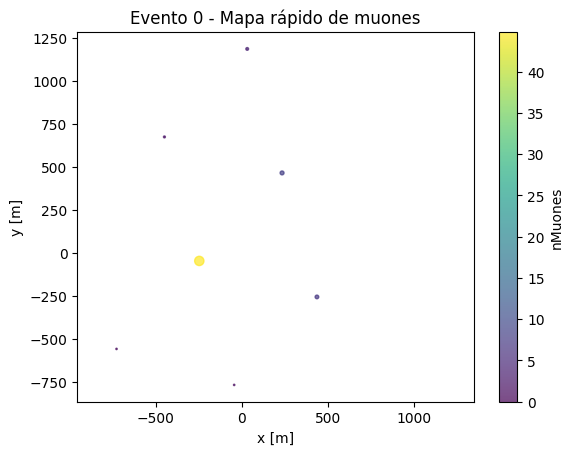

In [26]:
for event_idx, umdList in enumerate(df['umdCounters']):
    x = np.array([c['x_plane'] for c in umdList if c['x_plane'] is not None])
    y = np.array([c['y_plane'] for c in umdList if c['y_plane'] is not None])
    n = np.array([c['nMuones'] for c in umdList if c['x_plane'] is not None])
    
    plt.scatter(x, y, s=n, c=n, cmap='viridis', alpha=0.7)
    plt.colorbar(label="nMuones")
    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.title(f"Evento {event_idx} - Mapa rápido de muones")
    plt.axis('equal')
    plt.show()
    
    if event_idx >= 2:  # solo ver los primeros 3 eventos
        break


In [27]:
# -----------------------------
# Función principal de lectura
# -----------------------------
def readADST_surface(fname):
    """
    Leer archivos ADST y extraer información MC, SD y UMD para mapas de superficie.

    Parameters
    ----------
    fname : str or list of str
        Nombre(s) de archivo ADST a procesar.

    Returns
    -------
    pandas.DataFrame
        DataFrame por evento con columnas:
          - logE_MC, theta_MC, phi_MC, primary
          - logE_REC, theta_REC, phi_REC
          - coreUTM_X/Y, coreSite_X/Y
          - umdCounters : lista de diccionarios por cada counter con:
                counterId, nMuones, x_plane, y_plane, sdId, sdSignal
    """
    DataFiles = fname if isinstance(fname, list) else [fname]
    files = ROOT.std.vector('string')()
    for datfile in DataFiles:
        files.push_back(datfile)

    # Inicialización ADST
    file1 = ROOT.RecEventFile(files)
    event = ROOT.RecEvent()
    geo = ROOT.DetectorGeometry()
    file1.ReadDetectorGeometry(geo)
    file1.SetBuffers(event)

    data = []

    while file1.ReadNextEvent() == ROOT.RecEventFile.eSuccess:
        # ----------------- MC -----------------
        MCShower = event.GetGenShower()
        logE_MC = np.log10(MCShower.GetEnergy())
        theta_MC = MCShower.GetZenith() * 180.0/np.pi
        phi_MC = MCShower.GetAzimuth() * 180.0/np.pi
        primary = MCShower.GetShortPrimaryName()
        coreUTM = list(MCShower.GetCoreUTMCS())
        coreSite = list(MCShower.GetCoreSiteCS())

        # ----------------- REC -----------------
        sEvent = event.GetSDEvent()
        sShower = sEvent.GetSdRecShower()
        logE_REC = np.log10(sShower.GetEnergy())
        theta_REC = sShower.GetZenith() * 180.0/np.pi
        phi_REC = sShower.GetAzimuth() * 180.0/np.pi
        coreUTM_REC = list(sShower.GetCoreUTMCS())
        coreSite_REC = list(sShower.GetCoreSiteCS())

        # ----------------- MD -----------------
        mEvent = event.GetMDEvent()
        counterList = getCounterList(sEvent, mEvent)
        umdCounters = []

        for counter in counterList:
            #print(f"Counter {counter.GetId()}:")
            modules = getModuleList(counter)
            #for mod in modules:
                #print(f"  Mod {mod.GetId()}, nMuones={mod.GetNumberOfEstimatedMuons()}")
 
            if counter.IsRejected() or counter.IsSaturated():
                continue

            # Número total de muones por counter
            nMuones = counter.GetNumberOfMuons()  # <--- aquí el cambio clave

            # Coordenadas SD asociadas
            sdId = counter.GetSdPartnerId()
            sdStation = sEvent.GetStationById(sdId) if sEvent.HasStation(sdId) else None
            if sdStation:
                r = sdStation.GetSPDistance()  # distancia al core en el plano de la lluvia
                phi_rel = sdStation.GetAzimuthSP() - sShower.GetAzimuth()  # diferencia azimutal
                x_plane = r * np.cos(phi_rel)
                y_plane = r * np.sin(phi_rel)
                r_core = r   # <-- agregamos distancia al core directamente
            else:
                x_plane, y_plane, r_core = None, None, None

            umdCounters.append({
                "counterId": counter.GetId(),
                "nMuones": nMuones,
                "x_plane": x_plane,
                "y_plane": y_plane,
                "r_core": r_core,        # <-- nueva columna
                "sdId": sdId,
                "sdSignal": sdStation.GetTotalSignal() if sdStation else None
            })

        data.append({
            "logE_MC": logE_MC, "theta_MC": theta_MC, "phi_MC": phi_MC, "primary": primary,
            "logE_REC": logE_REC, "theta_REC": theta_REC, "phi_REC": phi_REC,
            "coreUTM_X": coreUTM[0], "coreUTM_Y": coreUTM[1],
            "coreSite_X": coreSite[0], "coreSite_Y": coreSite[1],
            "umdCounters": umdCounters
        })

    df = pd.DataFrame(data)
    return df


In [30]:
# Carpeta base
base_path = "/home/lsilva/Github/ADST_Marina_prot_175/"

# Rango de archivos y sufijos th
file_ranges = [
    (960, 1079, "th00"),
    (1080, 1199, "th12"),
    (1200, 1319, "th22"),
    (1320, 1439, "th32"),
    (1440, 1559, "th38")
]

all_dfs = []

for start, end, th in file_ranges:
    for i in range(start, end + 1):
        # Construimos el número con 6 dígitos: 750960, 751079, etc.
        dat_num = 750000 + i  # 750000 + 960 = 750960
        filename = f"ADST_e17m316prot-epos_{th}_DAT{dat_num}.root"
        fpath = os.path.join(base_path, filename)
        if os.path.exists(fpath):
            #print(f"Leyendo {fpath}...")
            df = readADST_surface(fpath)
            df["th"] = th
            df["file_idx"] = i
            all_dfs.append(df)
        else:
            print(f"Archivo no encontrado: {fpath}")

# Concatenar todos los DataFrames
df_all = pd.concat(all_dfs, ignore_index=True)
print("Lectura completa. Número total de eventos:", len(df_all))

# Guardar en .npz comprimido
np.savez_compressed("ADST_all_th.npz", df=df_all.to_dict("list"))
print("Guardado en ADST_all_th.npz")


  input file /home/lsilva/Github/ADST_Marina_prot_175/ADST_e17m316prot-epos_th00_DAT750960.root
  input file /home/lsilva/Github/ADST_Marina_prot_175/ADST_e17m316prot-epos_th00_DAT750961.root
  input file /home/lsilva/Github/ADST_Marina_prot_175/ADST_e17m316prot-epos_th00_DAT750962.root
  input file /home/lsilva/Github/ADST_Marina_prot_175/ADST_e17m316prot-epos_th00_DAT750963.root
  input file /home/lsilva/Github/ADST_Marina_prot_175/ADST_e17m316prot-epos_th00_DAT750964.root
  input file /home/lsilva/Github/ADST_Marina_prot_175/ADST_e17m316prot-epos_th00_DAT750965.root
  input file /home/lsilva/Github/ADST_Marina_prot_175/ADST_e17m316prot-epos_th00_DAT750966.root
  input file /home/lsilva/Github/ADST_Marina_prot_175/ADST_e17m316prot-epos_th00_DAT750967.root
  input file /home/lsilva/Github/ADST_Marina_prot_175/ADST_e17m316prot-epos_th00_DAT750968.root
  input file /home/lsilva/Github/ADST_Marina_prot_175/ADST_e17m316prot-epos_th00_DAT750969.root
  input file /home/lsilva/Github/ADST_Ma

Lectura completa. Número total de eventos: 600
Guardado en ADST_all_th.npz


In [37]:
# df_all: DataFrame que contiene todos los eventos leídos
df_umd = pd.DataFrame([{
    "theta": row["theta_MC"],
    "nMuones": c["nMuones"],
    "r_core": c["r_core"]
} for idx, row in df_all.iterrows() for c in row["umdCounters"] if c["nMuones"] > 0])

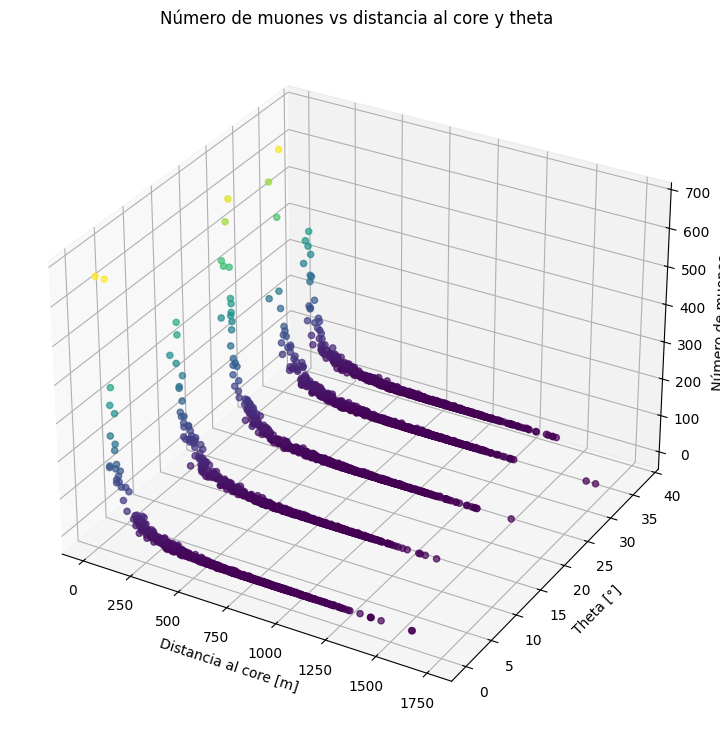

In [46]:
fig = plt.figure(figsize=(9,9))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df_umd["r_core"],
    df_umd["theta"],
    df_umd["nMuones"],
    c=df_umd["nMuones"], cmap="viridis", alpha=0.7
)

ax.set_xlabel("Distancia al core [m]")
ax.set_ylabel("Theta [°]")
ax.set_zlabel("Número de muones")
plt.title("Número de muones vs distancia al core y theta")
plt.show()


Resumen de diferencias angulares (deg):
                      mean       50%        std       min         max
delta_theta_deg   0.568567  0.492678   0.452994  0.000563    4.653664
delta_phi_deg    19.882569  1.306308  43.261904  0.002080  178.771732
ang_sep_deg       0.796575  0.728345   0.480866  0.052271    4.653664


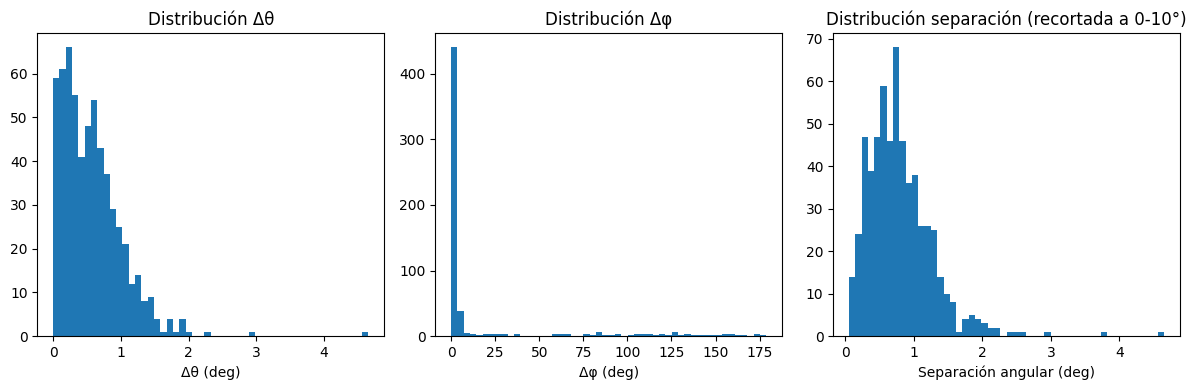

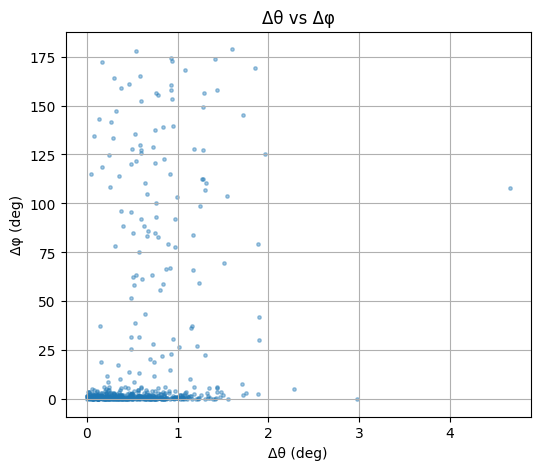

Total eventos: 600, eventos marcados como bad_reco: 119 (19.83%)

Contaje por criterio:
bad_theta        0
bad_phi        119
bad_ang_sep      0
dtype: int64


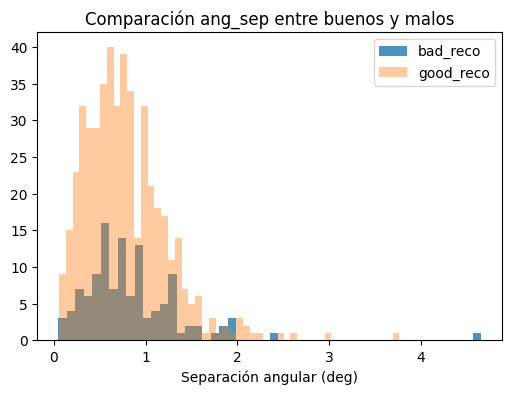

Eventos después del corte: 481
Guardado en ADST_all_th_with_reco_flags.npz


In [47]:
# ------------------------------
# Helpers angulares
# ------------------------------
def ang_diff_deg(a_deg, b_deg):
    """Diferencia de ángulos en grados en [-180,180], devolviendo el menor valor absoluto en grados."""
    d = (a_deg - b_deg + 180.0) % 360.0 - 180.0
    return d

def ang_diff_abs_deg(a_deg, b_deg):
    """Valor absoluto de la diferencia angular menor entre a y b en grados (0..180)."""
    return np.abs(ang_diff_deg(a_deg, b_deg))

def sph_dir_from_theta_phi(theta_deg, phi_deg):
    """
    Devuelve el vector unitario (x,y,z) para una dirección dada por
    theta (cenital en grados, 0 = vertical) y phi (azimut en grados, 0 = norte, convención del ADST).
    Nota: revisá la convención si necesitás otras (aquí asumimos theta = zenith).
    """
    th = np.deg2rad(theta_deg)
    ph = np.deg2rad(phi_deg)
    # Vector en coordenadas cartesianas (convención: z apunta hacia arriba)
    # Para cenital theta: z = cos(theta), x = sin(theta)*cos(phi), y = sin(theta)*sin(phi)
    x = np.sin(th) * np.cos(ph)
    y = np.sin(th) * np.sin(ph)
    z = np.cos(th)
    return np.vstack((x, y, z)).T  # shape (N,3)

def angular_separation_deg(theta1, phi1, theta2, phi2):
    """
    Separación angular entre dos direcciones dadas por (theta,phi) en grados.
    Calculada como arccos( dot(u1, u2) ) en grados. Protegida contra errores numéricos.
    """
    u1 = sph_dir_from_theta_phi(theta1, phi1)
    u2 = sph_dir_from_theta_phi(theta2, phi2)
    dots = np.sum(u1 * u2, axis=1)
    dots = np.clip(dots, -1.0, 1.0)
    ang_rad = np.arccos(dots)
    return np.rad2deg(ang_rad)

# ------------------------------
# Asumimos df_all ya cargado y con columnas:
# 'theta_MC','phi_MC','theta_REC','phi_REC'
# ------------------------------
# Si no, cargalo:
# loaded = np.load("ADST_all_th.npz", allow_pickle=True)
# df_all = pd.DataFrame(loaded["df"].item())

# Copia por seguridad para no tocar el original
df = df_all.copy()

# Convertir columnas a numpy (permite broadcasting)
theta_MC = df["theta_MC"].to_numpy(dtype=float)
phi_MC = df["phi_MC"].to_numpy(dtype=float)
theta_REC = df["theta_REC"].to_numpy(dtype=float)
phi_REC = df["phi_REC"].to_numpy(dtype=float)

# ------------------------------
# Cálculos angulares
# ------------------------------
df["delta_theta_deg"] = np.abs(theta_REC - theta_MC)   # diferencia directa en grados (0..inf)
df["delta_phi_deg"] = ang_diff_abs_deg(phi_REC, phi_MC)  # 0..180

# separación angular real en la esfera
df["ang_sep_deg"] = angular_separation_deg(theta_MC, phi_MC, theta_REC, phi_REC)

# también podés calcular una métrica relativa si querés:
df["rel_ang_sep_deg"] = df["ang_sep_deg"]  # por ahora igual

# ------------------------------
# Estadísticas rápidas
# ------------------------------
print("Resumen de diferencias angulares (deg):")
print(df[["delta_theta_deg", "delta_phi_deg", "ang_sep_deg"]].describe().T[["mean","50%","std","min","max"]])

# Histograms
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.hist(df["delta_theta_deg"].clip(0,50), bins=50)
plt.xlabel("Δθ (deg)")
plt.title("Distribución Δθ")

plt.subplot(1,3,2)
plt.hist(df["delta_phi_deg"].clip(0,180), bins=50)
plt.xlabel("Δφ (deg)")
plt.title("Distribución Δφ")

plt.subplot(1,3,3)
plt.hist(df["ang_sep_deg"].clip(0,10), bins=50)
plt.xlabel("Separación angular (deg)")
plt.title("Distribución separación (recortada a 0-10°)")

plt.tight_layout()
plt.show()

# Scatter Δθ vs Δφ para ver correlación
plt.figure(figsize=(6,5))
plt.scatter(df["delta_theta_deg"], df["delta_phi_deg"], s=6, alpha=0.4)
plt.xlabel("Δθ (deg)")
plt.ylabel("Δφ (deg)")
plt.title("Δθ vs Δφ")
plt.grid(True)
plt.show()

# ------------------------------
# Umbrales y marcado de malos eventos
# ------------------------------
# Propuestas (ajustables):
# - delta theta > 5° o
# - delta phi > 10° o
# - ang_sep_deg > 5°
th_delta_theta = 5.0
th_delta_phi = 10.0
th_ang_sep = 5.0

df["bad_theta"] = df["delta_theta_deg"] > th_delta_theta
df["bad_phi"] = df["delta_phi_deg"] > th_delta_phi
df["bad_ang_sep"] = df["ang_sep_deg"] > th_ang_sep

# Marca 'bad_reco' si cualquiera de las condiciones se cumple
df["bad_reco"] = df[["bad_theta", "bad_phi", "bad_ang_sep"]].any(axis=1)

# Resumen de recortes
n_total = len(df)
n_bad = df["bad_reco"].sum()
print(f"Total eventos: {n_total}, eventos marcados como bad_reco: {n_bad} ({100.0 * n_bad / n_total:.2f}%)")

print("\nContaje por criterio:")
print(df[["bad_theta","bad_phi","bad_ang_sep"]].sum())

# Distribución de 'ang_sep_deg' para eventos marcados
plt.figure(figsize=(6,4))
plt.hist(df.loc[df["bad_reco"], "ang_sep_deg"], bins=50, alpha=0.8, label="bad_reco")
plt.hist(df.loc[~df["bad_reco"], "ang_sep_deg"], bins=50, alpha=0.4, label="good_reco")
plt.xlabel("Separación angular (deg)")
plt.legend()
plt.title("Comparación ang_sep entre buenos y malos")
plt.show()

# ------------------------------
# Ejemplo: crear df limpio y df descartados
# ------------------------------
df_clean = df.loc[~df["bad_reco"]].reset_index(drop=True)
df_bad = df.loc[df["bad_reco"]].reset_index(drop=True)

print("Eventos después del corte:", len(df_clean))

# ------------------------------
# Guardar resultado con npz
# ------------------------------
# Guardamos ambas partes si querés
np.savez_compressed("ADST_all_th_with_reco_flags.npz",
                    df_all=df.to_dict("list"),
                    df_clean=df_clean.to_dict("list"),
                    df_bad=df_bad.to_dict("list"))
print("Guardado en ADST_all_th_with_reco_flags.npz")


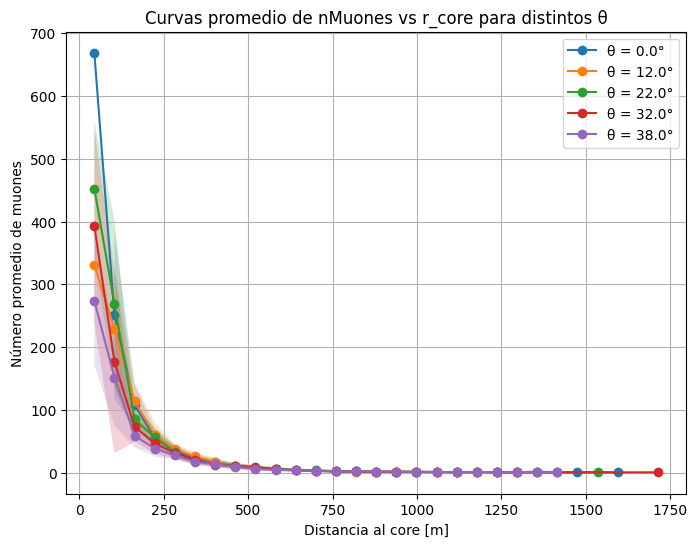

In [48]:
# Si df_umd ya existe con columnas: r_core [m], theta [deg], nMuones
# si no, cargalo antes (npz, csv, etc.)

# Redondeamos theta para agrupar (por si tiene ruido tipo 29.999 en vez de 30)
df_umd["theta_round"] = df_umd["theta"].round(1)

# Agrupamos por cada valor de theta
grouped = df_umd.groupby("theta_round")

# Calculamos el promedio y la desviación estándar de nMuones por bins de r_core
# primero definimos bins de distancia
bins = np.linspace(df_umd["r_core"].min(), df_umd["r_core"].max(), 30)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Guardamos las curvas promedio
curves = {}

for theta_val, group in grouped:
    # asignar cada r_core a un bin
    inds = np.digitize(group["r_core"], bins) - 1
    # promedio de nMuones en cada bin
    n_mu_mean = [group.loc[inds == i, "nMuones"].mean() for i in range(len(bin_centers))]
    n_mu_std = [group.loc[inds == i, "nMuones"].std() for i in range(len(bin_centers))]
    curves[theta_val] = (bin_centers, np.array(n_mu_mean), np.array(n_mu_std))

# ------------------------
# PLOT: curvas promedio
# ------------------------
plt.figure(figsize=(8,6))

for theta_val, (r, nmean, nstd) in curves.items():
    # Filtramos bins vacíos (NaN)
    mask = ~np.isnan(nmean)
    plt.plot(r[mask], nmean[mask], marker="o", label=f"θ = {theta_val:.1f}°")
    # opcional: bandas de error
    plt.fill_between(r[mask], nmean[mask]-nstd[mask], nmean[mask]+nstd[mask], alpha=0.2)

plt.xlabel("Distancia al core [m]")
plt.ylabel("Número promedio de muones")
plt.title("Curvas promedio de nMuones vs r_core para distintos θ")
plt.legend()
plt.grid(True)
plt.show()


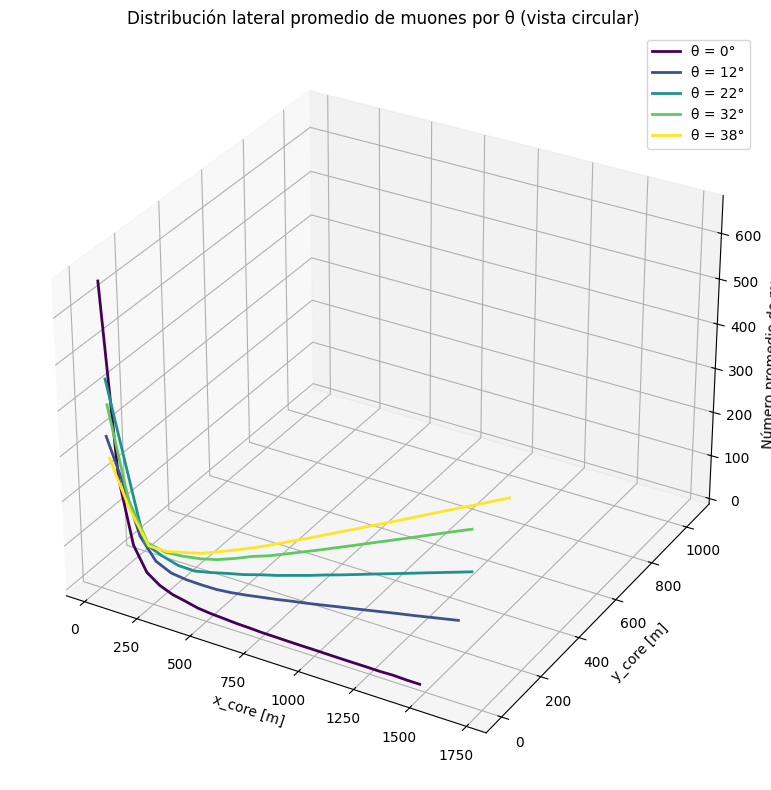

In [50]:
fig = plt.figure(figsize=(9, 8))
ax = fig.add_subplot(111, projection='3d')

colors = plt.cm.viridis(np.linspace(0, 1, len(curves)))  # una escala de color bonita

for (theta_deg, (r_vals, n_mean, n_std)), color in zip(sorted(curves.items()), colors):
    theta_rad = np.deg2rad(theta_deg)
    x = r_vals * np.cos(theta_rad)
    y = r_vals * np.sin(theta_rad)
    z = n_mean

    ax.plot(x, y, z, label=f"θ = {theta_deg:.0f}°", color=color, linewidth=2)
    # opcional: agregar barras de error en z
    # ax.fill_betweenx(r_vals, z - n_std, z + n_std, color=color, alpha=0.2)

ax.set_xlabel("x_core [m]")
ax.set_ylabel("y_core [m]")
ax.set_zlabel("Número promedio de muones")
ax.set_title("Distribución lateral promedio de muones por θ (vista circular)")
ax.legend()
plt.tight_layout()
plt.show()
